# Worksheet 1

## Exercise 1

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

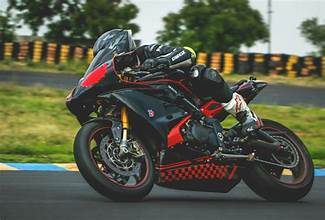

In [4]:
image = Image.open('/content/drive/MyDrive/AI and ML/Week1/OIP.jpg')
display(image)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
print(len( image . getbands () ))

3


In [7]:
image_array = np.array(image)

array([[[199, 217, 219],
        [201, 219, 221],
        [207, 223, 223],
        ...,
        [ 61,  73,  35],
        [ 61,  73,  33],
        [ 63,  75,  35]],

       [[202, 220, 222],
        [196, 214, 216],
        [199, 215, 215],
        ...,
        [ 60,  72,  34],
        [ 61,  73,  35],
        [ 63,  75,  35]],

       [[203, 221, 221],
        [190, 208, 208],
        [192, 208, 208],
        ...,
        [ 58,  69,  35],
        [ 61,  72,  38],
        [ 63,  75,  39]],

       ...,

       [[127, 141,  62],
        [126, 140,  61],
        [125, 139,  60],
        ...,
        [ 36,  32,  23],
        [ 42,  38,  29],
        [ 44,  41,  32]],

       [[115, 132,  52],
        [112, 129,  49],
        [110, 127,  47],
        ...,
        [ 48,  44,  33],
        [ 41,  37,  28],
        [ 42,  39,  30]],

       [[101, 118,  38],
        [ 98, 115,  35],
        [ 96, 113,  33],
        ...,
        [ 35,  28,  18],
        [ 38,  31,  23],
        [ 42,  38,  29]]], dtype=uint8)
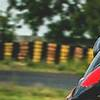

In [8]:
top_left = image_array[0:100,0:100]
display(top_left)

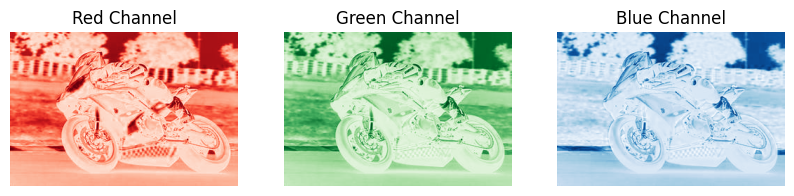

In [9]:
R = image_array[:, :, 0]
G = image_array[:, :, 1]
B = image_array[:, :, 2]

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

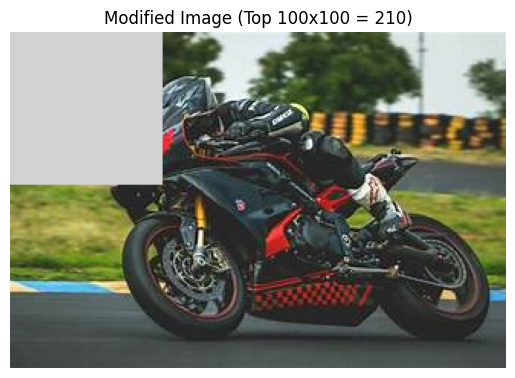

In [34]:
# Modified image with top left corner gray
modified = image_array.copy()
modified[0:100, 0:100] = 210
plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

## Exercise 2

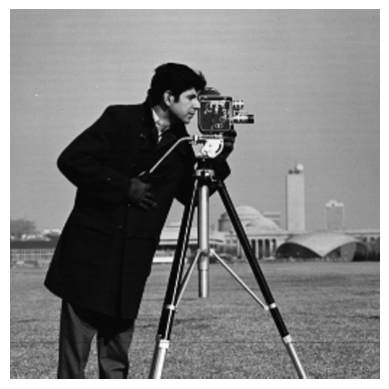

In [12]:
img_grayscale = Image.open('/content/drive/MyDrive/AI and ML/Week1/cameraman.png')
plt.imshow(img_grayscale, cmap='gray')
plt.axis("off")
plt.show()

In [13]:
img_array = np.array(img_grayscale)
print(img_array.shape)

(512, 512)


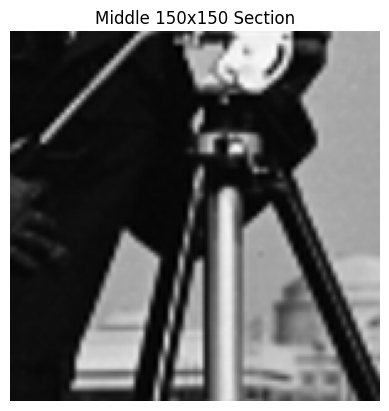

In [14]:
h,w = img_array.shape
center_h = h//2
center_w = w//2
middle_section = img_array[center_h-75:center_h+75, center_w-75:center_w+75]
plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

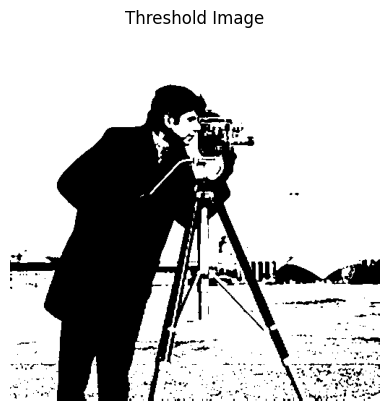

In [15]:
binary_image = img_array.copy()
binary_image[binary_image < 100] = 0
binary_image[binary_image >= 100] = 255
plt.imshow(binary_image, cmap="gray")
plt.title("Threshold Image")
plt.axis("off")
plt.show()

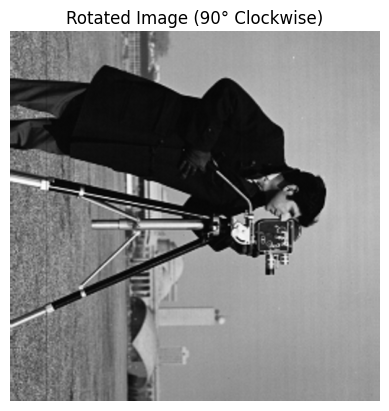

In [16]:
rotated_image = img_grayscale.rotate(-90)
plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

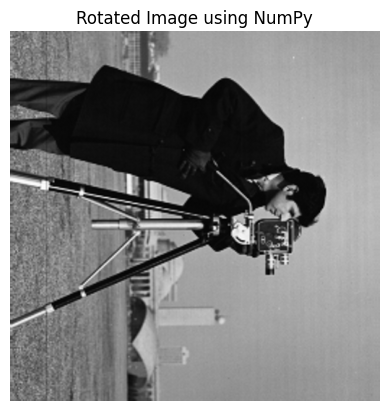

In [17]:
rotated_array = np.rot90(img_array, -1)
plt.imshow(rotated_array, cmap="gray")
plt.title("Rotated Image using NumPy")
plt.axis("off")
plt.show()

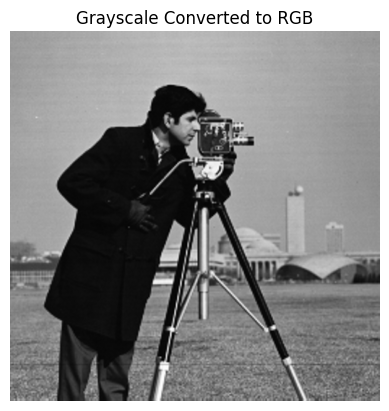

In [18]:
rgb_image = np.stack((img_array,)*3, axis=-1)
plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

In [19]:
image_from_array = Image.fromarray(rgb_image)
print(image_from_array.getbands())

('R', 'G', 'B')


## Exercise 3

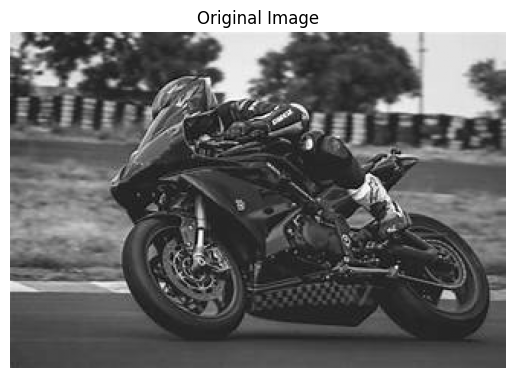

In [20]:
#Converting to grayscale
image = Image.open('/content/drive/MyDrive/AI and ML/Week1/OIP.jpg').convert("L")
img_array = np.array(image, dtype=float)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [21]:
print(img_array.shape)

(220, 325)


In [22]:
height,width = img_array.shape
data = img_array.reshape(height,width)

In [23]:
mean = np.mean(data, axis=0)
centered_data = data - mean

In [24]:
cov_matrix = np.cov(centered_data, rowvar=False)

In [25]:
# Computing eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [26]:
# Sorting eigen values and vectors in descending order
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

In [27]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


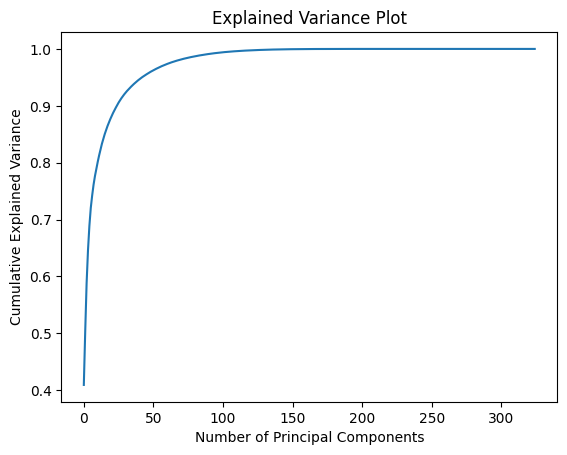

In [28]:
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.show()

In [29]:
k = 100
components = sorted_eigenvectors [: , : k ]

In [30]:
compressed_data = np . dot ( centered_data , components )

In [31]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) + mean

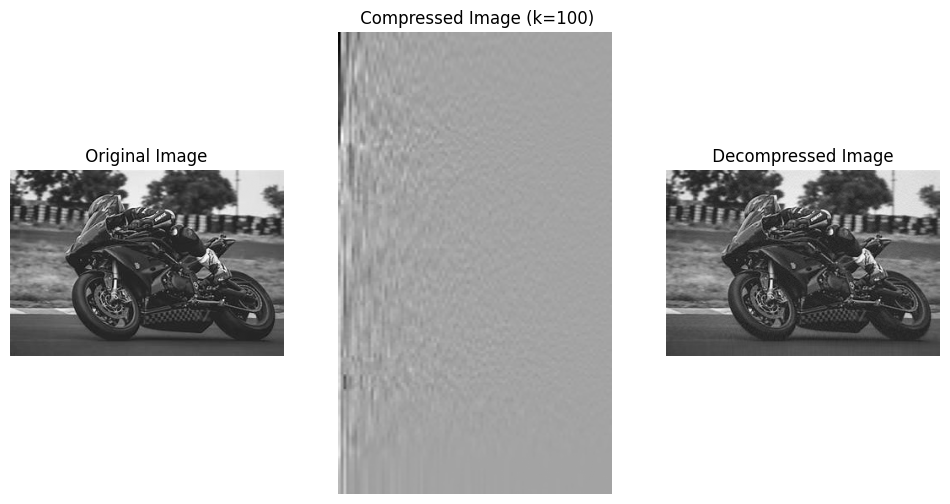

In [32]:
plt.figure ( figsize =(12 , 6) )
# Original Image
plt.subplot (1 , 3 , 1)
plt.imshow ( img_array , cmap ="gray")
plt.title (" Original Image ")
plt.axis ("off")
# Compressed Representation
plt.subplot (1 , 3 , 2)
plt.imshow (compressed_data.real, cmap ="gray", aspect ="auto")
plt.title ( f" Compressed Image (k={k})")
plt.axis ("off")
# Decompressed Image
plt.subplot (1 , 3 , 3)
plt.imshow ( decompressed_data.real , cmap ="gray")
plt.title (" Decompressed Image ")
plt.axis ("off")

plt.show()